# Zadanie 1

k     h                    Blad_wzor(1)              Blad_wzor(3)             
0     1.0e+00              7.1679664087311812e+00    4.5180387524455199e+00   
1     1.0e-01              6.4800050512274021e-01    9.7488377676805626e-02   
2     1.0e-02              5.4311135652046705e-02    9.4533926864892592e-04   
3     1.0e-03              5.3443964975810054e-03    9.4505286987178749e-06   
4     1.0e-04              5.3358746710552296e-04    9.4503965986092453e-08   
5     1.0e-05              5.3350263767626416e-05    9.4991214893980214e-10   
6     1.0e-06              5.3346278563459748e-06    1.0479928036488673e-10   
7     1.0e-07              5.3402349786679792e-07    6.2230220976289274e-12   
8     1.0e-08              2.5541352588476229e-08    3.3368920959730985e-09   
9     1.0e-09              1.5876811554349501e-07    4.7745813080979360e-08   
10    1.0e-10              1.1734995140066928e-06    6.3276489381536294e-08   
11    1.0e-11              1.4496175809508571e-05   

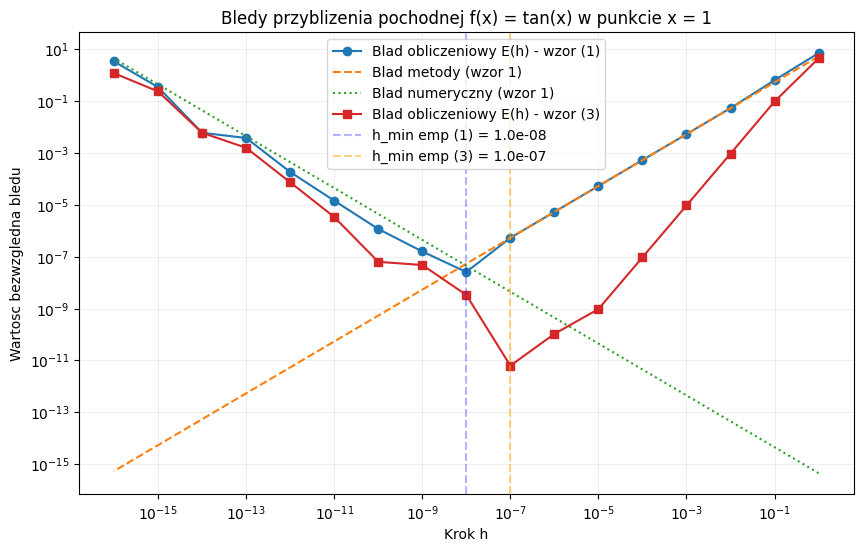

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.tan(x)

def df_exact(x):
    return 1.0 + np.tan(x)**2

def d2f_exact(x):
    cos_x = np.cos(x)
    return 2.0 * np.sin(x) / (cos_x**3)

def d3f_exact(x):
    cos_x = np.cos(x)
    sin_x = np.sin(x)
    return (2.0 * cos_x**2 + 6.0 * sin_x**2) / (cos_x**4)

x = 1.0
exact = df_exact(x)
eps = np.finfo(float).eps

M1 = np.abs(d2f_exact(x))
h_min_th_1 = 2.0 * np.sqrt(eps / M1)

M2 = np.abs(d3f_exact(x))
h_min_th_2 = np.cbrt(3.0 * eps / M2)

k_vals = np.arange(0, 17)
h_vals = 10.0**(-k_vals)

err_1_vals = []
err_2_vals = []

err_method_1_vals = []
err_num_1_vals = []

min_err_1 = float('inf')
h_min_emp_1 = 0.0

min_err_2 = float('inf')
h_min_emp_2 = 0.0

print(f"{'k':<5} {'h':<20} {'Blad_wzor(1)':<25} {'Blad_wzor(3)':<25}")

for k, h in zip(k_vals, h_vals):
    df_fw = (f(x + h) - f(x)) / h
    err_1 = np.abs(df_fw - exact)
    err_1_vals.append(err_1)
    
    err_method_1 = M1 * h / 2.0
    err_num_1 = 2.0 * eps / h
    err_method_1_vals.append(err_method_1)
    err_num_1_vals.append(err_num_1)
    
    if err_1 < min_err_1:
        min_err_1 = err_1
        h_min_emp_1 = h
        
    df_cd = (f(x + h) - f(x - h)) / (2.0 * h)
    err_2 = np.abs(df_cd - exact)
    err_2_vals.append(err_2)
    
    if err_2 < min_err_2:
        min_err_2 = err_2
        h_min_emp_2 = h
        
    print(f"{k:<5} {h:<20.1e} {err_1:<25.16e} {err_2:<25.16e}")

print("\n--- WZOR (1) Roznica progresywna ---")
print(f"h_min (empiryczne):  {h_min_emp_1}")
print(f"h_min (teoretyczne): {h_min_th_1}")
print(f"Minimalny blad E(h_min): {min_err_1}")

print("\n--- WZOR (3) Roznica centralna ---")
print(f"h_min (empiryczne):  {h_min_emp_2}")
print(f"h_min (teoretyczne): {h_min_th_2}")
print(f"Minimalny blad E(h_min): {min_err_2}")

print("\n--- POROWNANIE ---")
if min_err_2 < min_err_1:
    print("Metoda roznic centralnych (wzor 3) jest dokladniejsza.")
else:
    print("Metoda roznic progresywnych (wzor 1) jest dokladniejsza.")

plt.figure(figsize=(10, 6))
plt.loglog(h_vals, err_1_vals, 'o-', label='Blad obliczeniowy E(h) - wzor (1)')
plt.loglog(h_vals, err_method_1_vals, '--', label='Blad metody (wzor 1)')
plt.loglog(h_vals, err_num_1_vals, ':', label='Blad numeryczny (wzor 1)')
plt.loglog(h_vals, err_2_vals, 's-', label='Blad obliczeniowy E(h) - wzor (3)')

plt.axvline(h_min_emp_1, color='blue', alpha=0.3, linestyle='--', label=f'h_min emp (1) = {h_min_emp_1:.1e}')
plt.axvline(h_min_emp_2, color='orange', alpha=0.5, linestyle='--', label=f'h_min emp (3) = {h_min_emp_2:.1e}')

plt.xlabel('Krok h')
plt.ylabel('Wartosc bezwzgledna bledu')
plt.title('Bledy przyblizenia pochodnej f(x) = tan(x) w punkcie x = 1')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

# Zadanie 2

In [12]:
import decimal as dec

dec.getcontext().prec = 10

In [13]:
def calculate_error_a():
    x = dec.Decimal('1e-11')
    
    f1 = (x + 1).sqrt() - 1
    f1_stable = x / ((x + 1).sqrt() + 1)
    
    print(f"f1: {f1}, f1_stable: {f1_stable}, error: {abs(f1 - f1_stable)}")
   

In [14]:
def calculate_error_b():
    x = dec.Decimal('1.0000000001')
    y = dec.Decimal('1.0000000000')
    
    f2 = (x*x) - (y*y)
    f2_stable = (x - y) * (x + y)
    
    print(f"f2: {f2}, f2_stable: {f2_stable}, error: {abs(f2 - f2_stable)}")

In [15]:
calculate_error_a()
calculate_error_b()

f1: 0.00000, f1_stable: 5E-12, error: 5E-12
f2: 0E-9, f2_stable: 2.000000000E-10, error: 2.000000000E-10


# Zadanie 3

 k |       x |     Wzor (5) |     Wzor (8) |       Taylor |        expm1
---------------------------------------------------------------------------
 0 | 1.0e+00 | 1.7182818285 | 1.7182818285 | 1.7182818011 | 1.7182818285
 1 | 1.0e-01 | 1.0517091808 | 1.0517091808 | 1.0517091808 | 1.0517091808
 2 | 1.0e-02 | 1.0050167084 | 1.0050167084 | 1.0050167084 | 1.0050167084
 3 | 1.0e-03 | 1.0005001667 | 1.0005001667 | 1.0005001667 | 1.0005001667
 4 | 1.0e-04 | 1.0000500017 | 1.0000500017 | 1.0000500017 | 1.0000500017
 5 | 1.0e-05 | 1.0000050000 | 1.0000050000 | 1.0000050000 | 1.0000050000
 6 | 1.0e-06 | 1.0000005000 | 1.0000005000 | 1.0000005000 | 1.0000005000
 7 | 1.0e-07 | 1.0000000494 | 1.0000000500 | 1.0000000500 | 1.0000000500
 8 | 1.0e-08 | 0.9999999939 | 1.0000000050 | 1.0000000050 | 1.0000000050
 9 | 1.0e-09 | 1.0000000827 | 1.0000000005 | 1.0000000005 | 1.0000000005
10 | 1.0e-10 | 1.0000000827 | 1.0000000001 | 1.0000000001 | 1.0000000001
11 | 1.0e-11 | 1.0000000827 | 1.0000000000 | 1.0

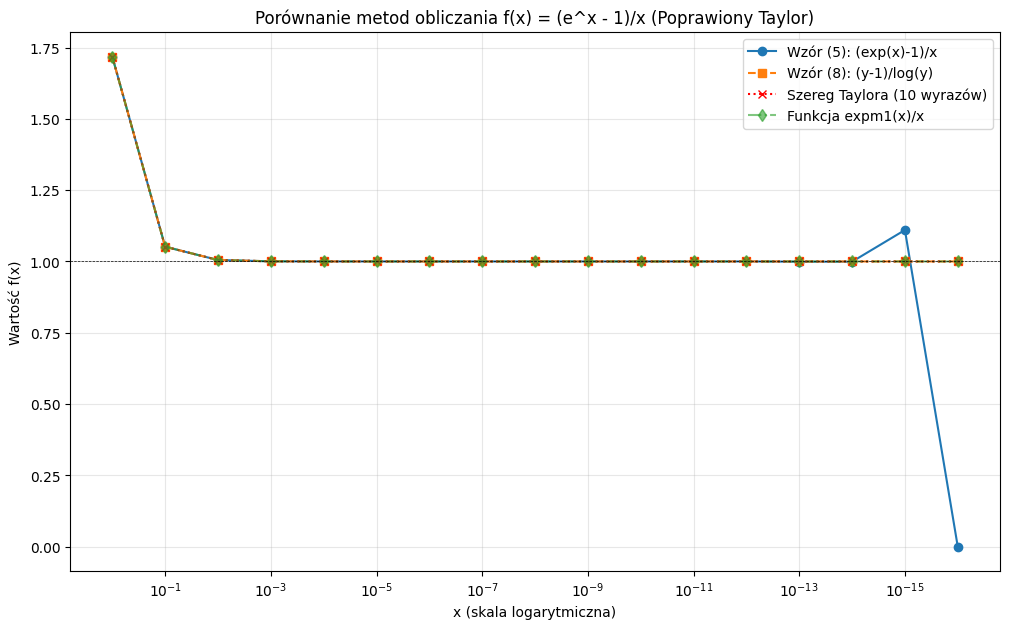

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

def f1(x):
    if x == 0:
        return 1.0
    return (np.exp(x) - 1.0) / x

def f2(x):
    y = np.exp(x)
    if y == 1.0:
        return 1.0
    return (y - 1.0) / np.log(y)

def f3(x):
    # Rozszerzony szereg Taylora (do n=10), aby lepiej działał dla x bliskich 1
    # f(x) = 1 + x/2! + x^2/3! + x^3/4! + ... + x^n/(n+1)!
    n_terms = 10
    result = 0.0
    for i in range(n_terms):
        result += (x**i) / factorial(i + 1)
    return result

def f4(x):
    if x == 0:
        return 1.0
    return np.expm1(x) / x

k_vals = np.arange(0, 17)
x_vals = 10.0**(-k_vals)

res1 = [f1(x) for x in x_vals]
res2 = [f2(x) for x in x_vals]
res3 = [f3(x) for x in x_vals]
res4 = [f4(x) for x in x_vals]

print(f"{'k':>2} | {'x':>7} | {'Wzor (5)':>12} | {'Wzor (8)':>12} | {'Taylor':>12} | {'expm1':>12}")
print("-" * 75)
for k, x, r1, r2, r3, r4 in zip(k_vals, x_vals, res1, res2, res3, res4):
    print(f"{k:2} | {x:7.1e} | {r1:12.10f} | {r2:12.10f} | {r3:12.10f} | {r4:12.10f}")

plt.figure(figsize=(12, 7))
plt.semilogx(x_vals, res1, 'o-', label='Wzór (5): (exp(x)-1)/x')
plt.semilogx(x_vals, res2, 's--', label='Wzór (8): (y-1)/log(y)')
plt.semilogx(x_vals, res3, 'x:', label='Szereg Taylora (10 wyrazów)', color='red')
plt.semilogx(x_vals, res4, 'd-.', label='Funkcja expm1(x)/x', alpha=0.6)

plt.axhline(1.0, color='black', lw=0.5, ls='--')
plt.xlabel('x (skala logarytmiczna)')
plt.ylabel('Wartość f(x)')
plt.title('Porównanie metod obliczania f(x) = (e^x - 1)/x (Poprawiony Taylor)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.gca().invert_xaxis()
plt.show()

# Zadanie 4

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
def generate_numbers(n):
    return np.random.uniform(0, 1, n).astype(np.float32)

def relative_error(measured, exact):
    return abs(measured - exact) / exact

def sum_a(numbers):
    total = np.float64(0.0)
    for x in numbers:
        total += np.float64(x)
    return total

def sum_b(numbers):
    total = np.float32(0.0)
    for x in numbers:
        total = np.float32(total + x)
    return total

def sum_c(numbers):
    total = np.float32(0.0)
    err = np.float32(0.0)
    for x in numbers:
        y = np.float32(x - err)
        temp = np.float32(total + y)
        err = np.float32(np.float32(temp - total) - y)
        total = temp
    return total

def sum_d(numbers):
    sorted_nums = np.sort(np.abs(numbers))
    total = np.float32(0.0)
    for x in sorted_nums:
        total = np.float32(total + x)
    return total

def sum_e(numbers):
    sorted_nums = np.sort(np.abs(numbers))[::-1]
    total = np.float32(0.0)
    for x in sorted_nums:
        total = np.float32(total + x)
    return total

In [ ]:
ks = np.arange(4, 9)
ns = 10**ks

errors = { "a": [], "b": [], "c": [], "d": [], "e": [] }

for n in ns:
    data = generate_numbers(n)
    exact_sum = math.fsum(data)
    
    errors["a"].append(relative_error(sum_a(data), exact_sum))
    errors["b"].append(relative_error(sum_b(data), exact_sum))
    errors["c"].append(relative_error(sum_c(data), exact_sum))
    errors["d"].append(relative_error(sum_d(data), exact_sum))
    errors["e"].append(relative_error(sum_e(data), exact_sum))

plt.figure(figsize=(10, 6))
plt.loglog(ns, errors["a"], label='(a) Serial (float64 acc)', marker='o')
plt.loglog(ns, errors["b"], label='(b) Serial (float32 acc)', marker='s')
plt.loglog(ns, errors["c"], label='(c) Kahan (float32)', marker='^')
plt.loglog(ns, errors["d"], label='(d) Ascending', marker='x')
plt.loglog(ns, errors["e"], label='(e) Descending', marker='d')

plt.title('Błąd względny sumowania w zależności od n')
plt.xlabel('n (liczba elementów)')
plt.ylabel('Błąd względny')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()